# **Do Spotify audio features capture a meaningful underlying structure of music, and how does this structure compare to genre labels and popularity?**

*names*

# **1. Intro**
...

---

# **2. Global Pipeline**

## **2.1. Overall ML Strategy** READ

This project is intentionally designed as a multi-perspective machine learning study rather than a single task. For that reason, we approach the Spotify dataset as a structured environment in which different modeling tasks can reveal different aspects of music.

The central idea is that the same acoustic feature space can support multiple legitimate ML questions, each with a different interpretation. In some cases, we want to predict a label from the audio features, such as genre or popularity. In other cases, we want to remove labels entirely and explore how songs organize themselves naturally. These are not competing approaches. They are complementary views of the same data.

Our project is therefore built around four main analytical arcs:*

Each block addresses a distinct research question. Genre classification tests whether playlist categories correspond to stable acoustic patterns. Popularity modeling asks whether musical success is reflected in sound, while also recognizing that popularity is shaped by many external variables not present in the dataset. Clustering investigates whether the songs contain latent musical archetypes that cut across Spotify’s labels. Dimensionality reduction provides a visual and geometric representation of the acoustic space, helping us interpret the results of the supervised and unsupervised analyses.

At the global level, the project follows a modular pipeline:

The main steps of the machine learning workflow are:

1. **Data Loading and Exploration**  
   We begin by loading the dataset and understanding its structure, variable types, and distributions. This step allows us to identify potential targets, features, and data quality issues.

2. **Data Cleaning and Curation**  
   We clean the dataset by handling duplicates, ensuring consistency, and defining the correct unit of analysis (song-level vs playlist-level). This step ensures that the data is reliable and suitable for modeling.

3. **Data Splitting**  
   The dataset is split into training, validation, and test sets before any transformation that learns from the data. This prevents data leakage and ensures that model evaluation reflects true generalization.

4. **Managing Missing Values**  
   Missing values are identified and handled using appropriate imputation strategies. All imputation parameters are computed on the training data only to avoid leakage.

5. **Encoding Categorical Variables**  
   Categorical variables are transformed into numerical representations where needed, with careful distinction between features and target variables.

6. **Feature Engineering and Selection**  
   A core set of numerical audio features is defined globally, and task-specific feature transformations are introduced later within each modeling block. This allows us to balance consistency with flexibility.

7. **Feature Scaling**  
   Numerical features are scaled to ensure comparability across variables, which is especially important for distance-based models, clustering, and neural networks.

8. **Model Training and Evaluation (Task-Specific)**  
   For each analytical block, we:
- Define the prediction target (if supervised)
- Select appropriate models
- Train models on the training set
- Tune using validation data
- Evaluate performance using suitable metrics

10. **Interpretation and Comparison of Results**  
   We analyze model outputs to understand:
-  Which features are important
- How different models behave
- What the results reveal about the structure of the data

11. **Cross-Block Synthesis and Conclusions**  
    Finally, we integrate findings across all modeling tasks to draw broader conclusions about musical structure, genre, and popularity.

A final reason for this strategy is interpretive strength. If the project only included one target, our conclusions would remain narrow. By combining classification, prediction, clustering, and visualization, we can compare what is easy to learn from the audio features and what is not. That contrast is meaningful. If genre is predictable but popularity is not, that tells us something important about the difference between musical structure and social reception. If clusters cut across genres, that tells us something about the limits of playlist labels as representations of musical reality.

In short, the overall ML strategy of this project is to use one dataset, one coherent preprocessing foundation, and multiple machine learning perspectives to produce a richer and more revealing analysis of music.

## **2. Data Loading & Exploration**

The first step is to load the dataset and understand what we're actually working with before building any models. This means checking the structure of the data, the types of variables, and what each column represents.

The dataset contains different kinds of information. Some columns are identifiers (like track or playlist IDs), which are not useful for prediction. Others are descriptive text, such as track names or artists, which may carry some contextual information. We also have playlist-level labels like genre and subgenre, the popularity score, and a set of numerical audio features (such as danceability, energy, tempo, etc.), which describe the music itself.

This distinction is important for the project. Audio features represent intrinsic properties of the songs, while text and playlist labels reflect external or contextual information. Since our goal is to compare different representations of music, separating these groups early helps us stay consistent in how we use them later.

For the supervised part of the project, we use track popularity as the target variable. It is originally a numerical value between 0 and 100, but instead of predicting the exact value, we convert it into three categories: low, medium, and high popularity. This makes the problem easier to interpret and better suited for classification models. The categories are defined using quantiles to ensure a balanced distribution of classes.

During exploration, we also look at the distribution of the main variables. For numerical features, we check ranges and general shape (for example, whether values are skewed or concentrated). For categorical variables like genre, we look at how balanced the classes are. We also inspect the distribution of popularity. These checks are important because imbalance or overlapping distributions can affect our models' performance and our interpretation of the results.

One important observation is that **the same track can appear multiple times across different playlists**. This means the dataset is playlist-based rather than track-based, so the observations are not fully independent. We decided not to remove the duplicates, because they represent different contexts in each playlist, and if we deleted them, we would be losing some playlist/context information. But we also have to acknowledge that this may introduce bias and it needs to be considered during interpretation.

In [2]:
# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DISPLAY AND PLOT SETTINGS - COSMETIC PURPOSES ONLY

pd.set_option("display.max_columns", None) # Display settings
pd.set_option("display.width", 120)
sns.set(style="whitegrid") # Plot settings

In [3]:
# LOAD DATASET

df = pd.read_csv("spotify_songs.csv")
print(f"Shape: {df.shape}") # Rows = samples ; Columns = features ; 33k observations, 23 features

Shape: (32833, 23)


The dataset contains 32833 observations and 23 features. This size is sufficient for both supervised and unsupervised learning tasks. We should have more than enough data to find significant patterns.

In [4]:
# FIRST LOOK AT THE DATA

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes) # Numeric vs categorical variables

df.info()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052



Column names:
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Data types:


,0
track_id,object
track_name,object
track_artist,object
track_popularity,int64
track_album_id,object
track_album_name,object
track_album_release_date,object
playlist_name,object
playlist_id,object
playlist_genre,object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

A quick inspection of the dataset confirms that each row corresponds to a track within a playlist. The data includes a mix of identifiers, textual information, and numerical audio features, which will need to be handled differently during preprocessing.

In [30]:
# MISSING VALUES

missing_counts = df.isnull().sum().sort_values(ascending=False) # Missing values - almost none
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent})

display(missing_summary[missing_summary["missing_count"] > 0])

,missing_count,missing_percent
track_name,5,0.015229
track_artist,5,0.015229
track_album_name,5,0.015229


The dataset contains almost no missing values, with only a few missing entries in text-related columns. Given the very low proportion, these can be handled very safely, without really affecting the dataset.

Note: after converting the date, we uncovered that there are more missing values than it appears here. We will handle them later.

In [6]:
# DUPLICATES

total_duplicates = df.duplicated().sum()
print(f"\nNumber of fully duplicated rows: {total_duplicates}") # 0

if "track_id" in df.columns:
    duplicate_tracks = df["track_id"].duplicated().sum()
    print(f"Number of duplicated track_id values: {duplicate_tracks}") # 4477


Number of fully duplicated rows: 0
Number of duplicated track_id values: 4477


As we mentioned before, many tracks appear in different playlists. We won't remove the duplicate entries but we need to take this into account in the future to avoid bias as much as possible.

In [7]:
# COLUMN GROUPING

identifier_cols = [
    col for col in ["track_id", "track_album_id", "playlist_id"] if col in df.columns]

text_metadata_cols = [
    col for col in ["track_name", "track_artist", "track_album_name", "playlist_name"] if col in df.columns]

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nIdentifier columns:")
print(identifier_cols)

print("\nText / metadata columns:")
print(text_metadata_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)


Identifier columns:
['track_id', 'track_album_id', 'playlist_id']

Text / metadata columns:
['track_name', 'track_artist', 'track_album_name', 'playlist_name']

Categorical columns:
['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']

Numerical columns:
['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


Columns were grouped into identifiers, text metadata, categorical variables, and numerical features. This helps clarify which variables are suitable for modeling. In particular, audio features will serve as the main representation of the music, while text and playlist labels provide contextual information.

In [8]:
# DESCRIPTIVE STATISTICS

print("\nNumerical summary:")
display(df[numerical_cols].describe().T)

print("\nCategorical summary:")
display(df[categorical_cols].describe().T)


Numerical summary:


,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477081,24.984074,0.000000,24.0000,45.000000,62.00000,100.000
danceability,32833.0,0.654850,0.145085,0.000000,0.5630,0.672000,0.76100,0.983
energy,32833.0,0.698619,0.180910,0.000175,0.5810,0.721000,0.84000,1.000
key,32833.0,5.374471,3.611657,0.000000,2.0000,6.000000,9.00000,11.000
loudness,32833.0,-6.719499,2.988436,-46.448000,-8.1710,-6.166000,-4.64500,1.275
mode,32833.0,0.565711,0.495671,0.000000,0.0000,1.000000,1.00000,1.000
speechiness,32833.0,0.107068,0.101314,0.000000,0.0410,0.062500,0.13200,0.918
acousticness,32833.0,0.175334,0.219633,0.000000,0.0151,0.080400,0.25500,0.994
instrumentalness,32833.0,0.084747,0.224230,0.000000,0.0000,0.000016,0.00483,0.994
liveness,32833.0,0.190176,0.154317,0.000000,0.0927,0.127000,0.24800,0.996



Categorical summary:


,count,unique,top,freq
track_id,32833,28356,7BKLCZ1jbUBVqRi2FVlTVw,10
track_name,32828,23449,Poison,22
track_artist,32828,10692,Martin Garrix,161
track_album_id,32833,22545,5L1xcowSxwzFUSJzvyMp48,42
track_album_name,32828,19743,Greatest Hits,139
track_album_release_date,32833,4530,2020-01-10,270
playlist_name,32833,449,Indie Poptimism,308
playlist_id,32833,471,4JkkvMpVl4lSioqQjeAL0q,247
playlist_genre,32833,6,edm,6043
playlist_subgenre,32833,24,progressive electro house,1809


The numerical summary shows that audio features are generally well-scaled within expected ranges, although some variables (such as tempo and duration) have wider ranges. Feature scaling will be important for certain models later on.

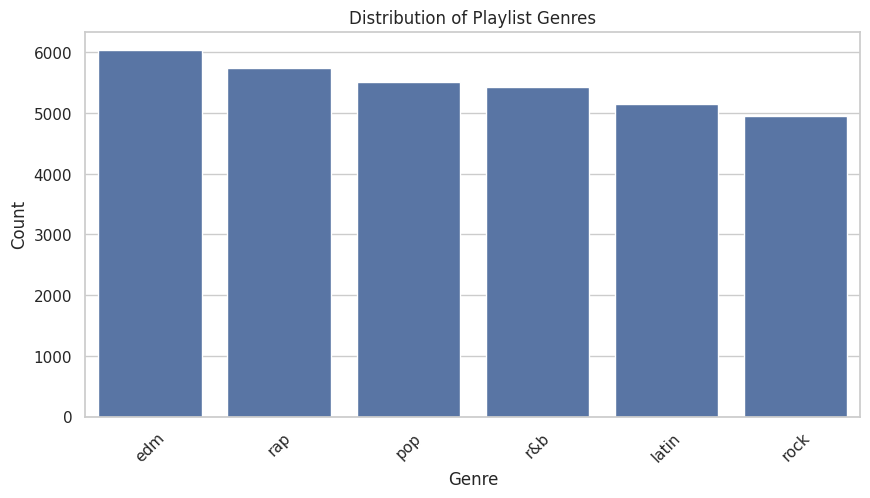

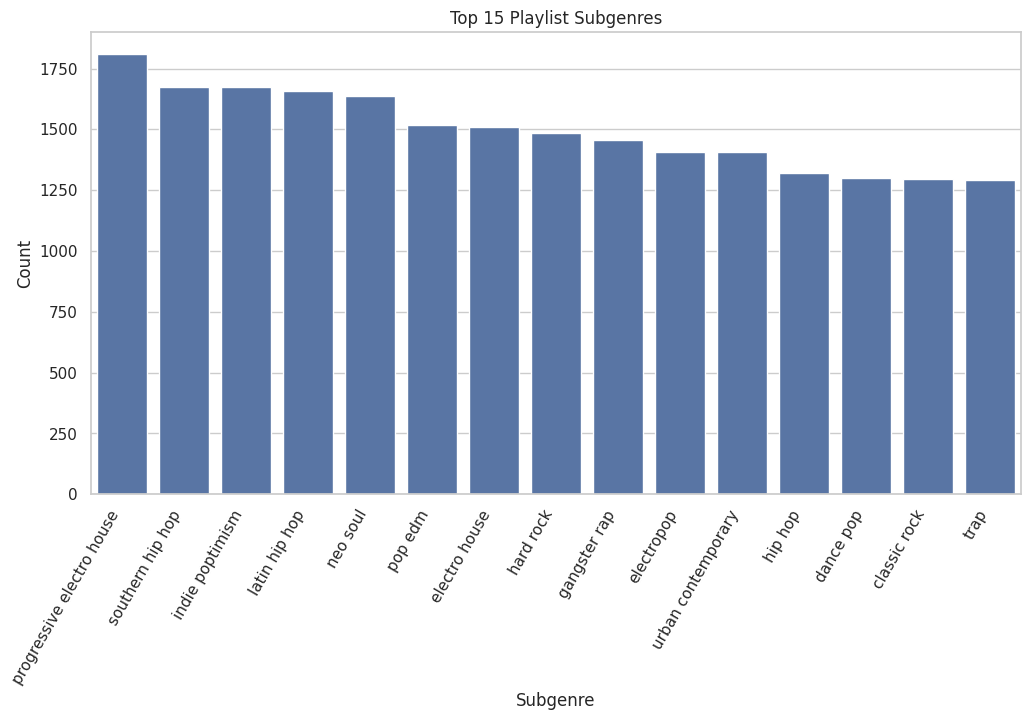

In [9]:
# CLASS DISTRIBUTION (GENRE AND SUBGENRE)

if "playlist_genre" in df.columns:
    plt.figure(figsize=(10, 5))
    genre_counts = df["playlist_genre"].value_counts()
    sns.barplot(x=genre_counts.index, y=genre_counts.values)
    plt.title("Distribution of Playlist Genres")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

if "playlist_subgenre" in df.columns:
    plt.figure(figsize=(12, 6))
    subgenre_counts = df["playlist_subgenre"].value_counts().head(15)
    sns.barplot(x=subgenre_counts.index, y=subgenre_counts.values)
    plt.title("Top 15 Playlist Subgenres")
    plt.xlabel("Subgenre")
    plt.ylabel("Count")
    plt.xticks(rotation=60, ha="right")
    plt.show()

The distribution of genres and subgenres is not perfectly balanced, with some categories appearing much more frequently than others. This imbalance can affect classification performance and reinforces the need for appropriate evaluation metrics such as macro F1.

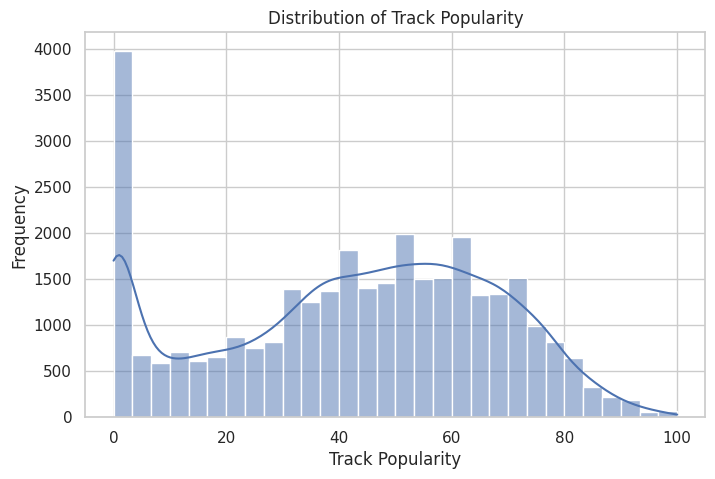

In [10]:
# POPULARITY DISTRIBUTION

if "track_popularity" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["track_popularity"], bins=30, kde=True)
    plt.title("Distribution of Track Popularity")
    plt.xlabel("Track Popularity")
    plt.ylabel("Frequency")
    plt.show()

Track popularity is spread across the full range from 0 to 100, without extreme concentration in a single region. This supports transforming it into balanced categories for classification using quantiles rather than treating it as a regression problem.

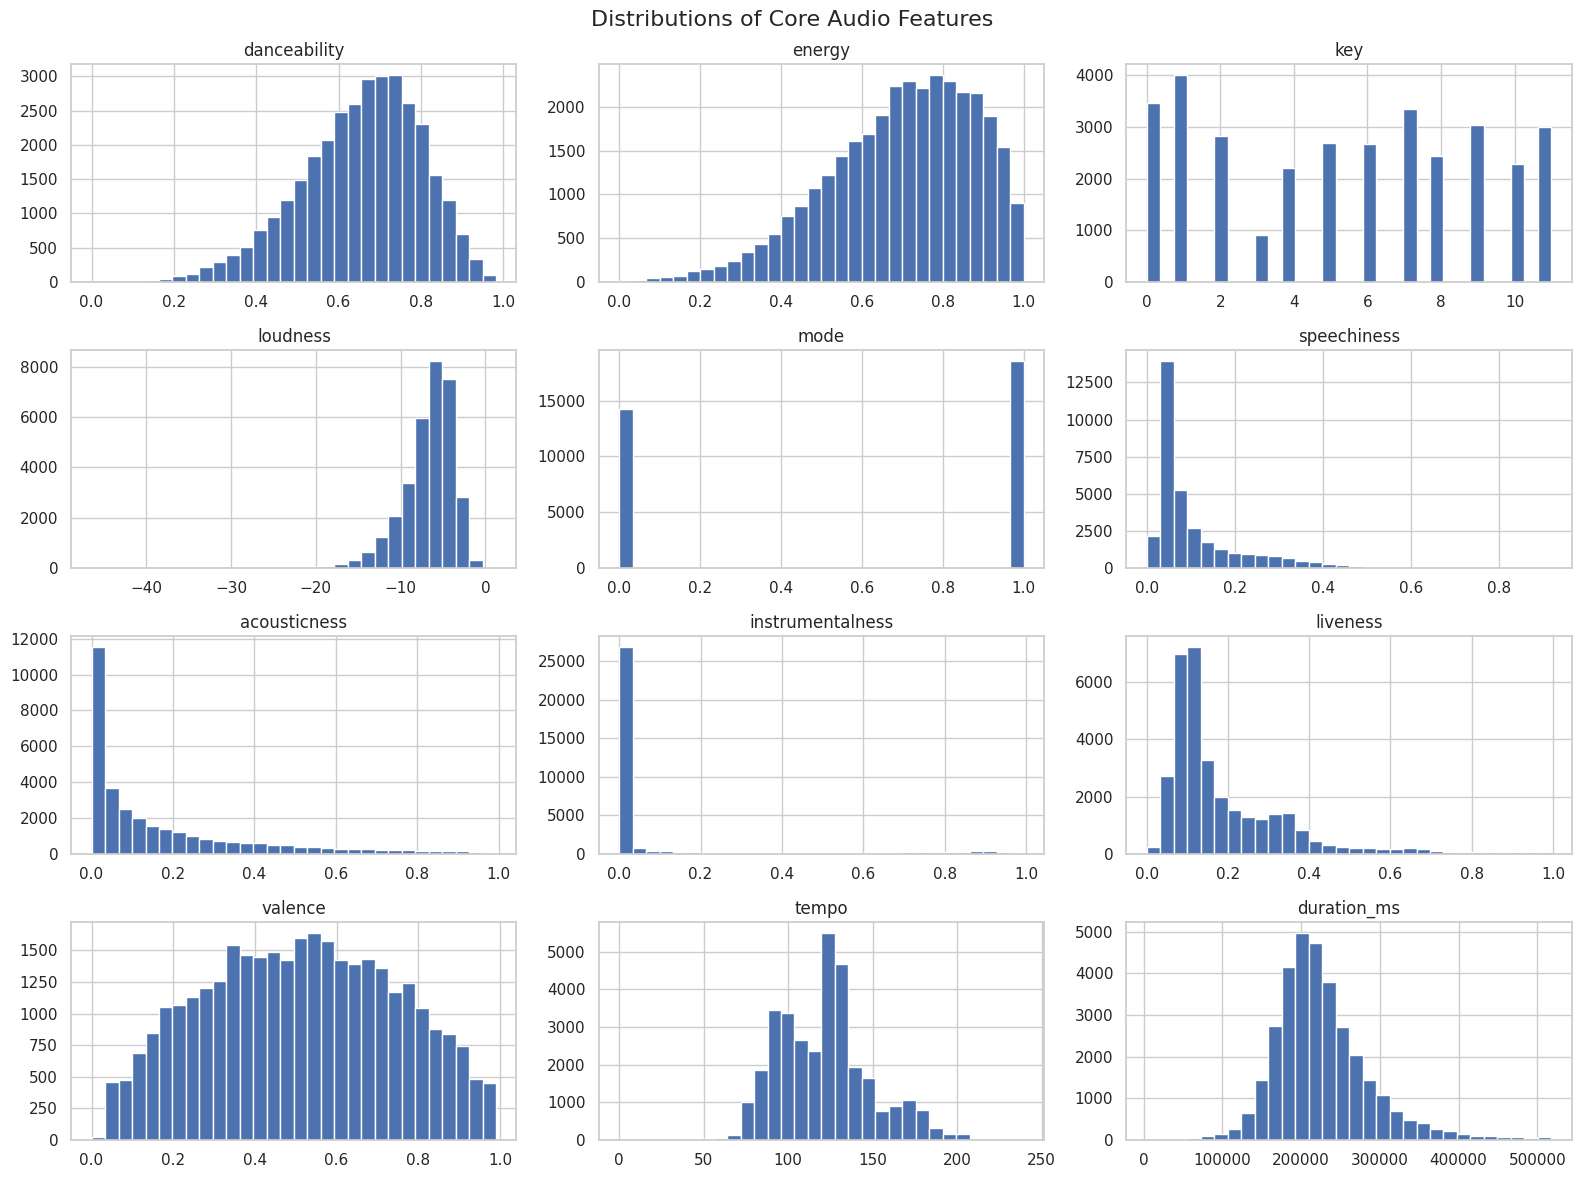

In [11]:
# AUDIO FEATURES DISTRIBUTION

audio_features = [
    "danceability", "energy", "key", "loudness", "mode", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms"]

audio_features = [col for col in audio_features if col in df.columns]

df[audio_features].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distributions of Core Audio Features", fontsize=16)
plt.tight_layout()
plt.show()

The distributions of audio features vary across variables, with some showing skewness or concentration around specific values. Different features may carry different levels of information and may require scaling or transformation.

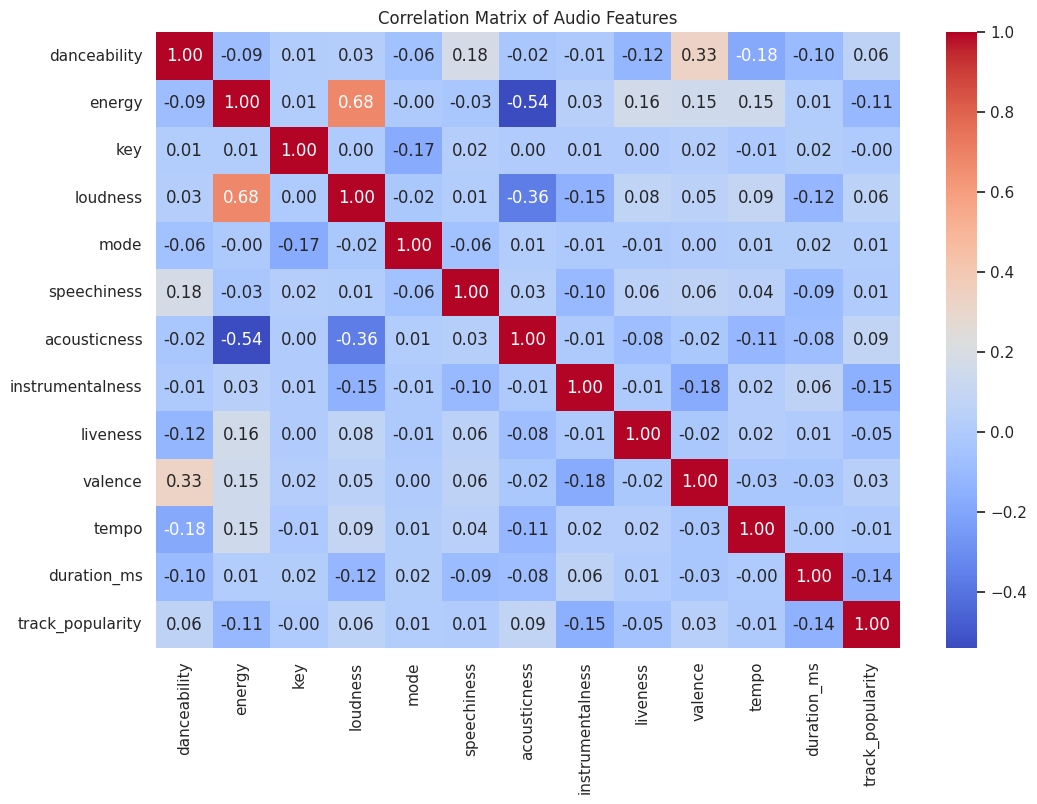

In [12]:
# CORRELATION HEATMAP

plt.figure(figsize=(12, 8))
corr_matrix = df[audio_features + (["track_popularity"] if "track_popularity" in df.columns else [])].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Audio Features")
plt.show()

The correlation analysis shows generally weak relationships between individual audio features and track popularity. This means that popularity may not be strongly explained by audio features alone, which aligns with the idea that external factors also play a role.

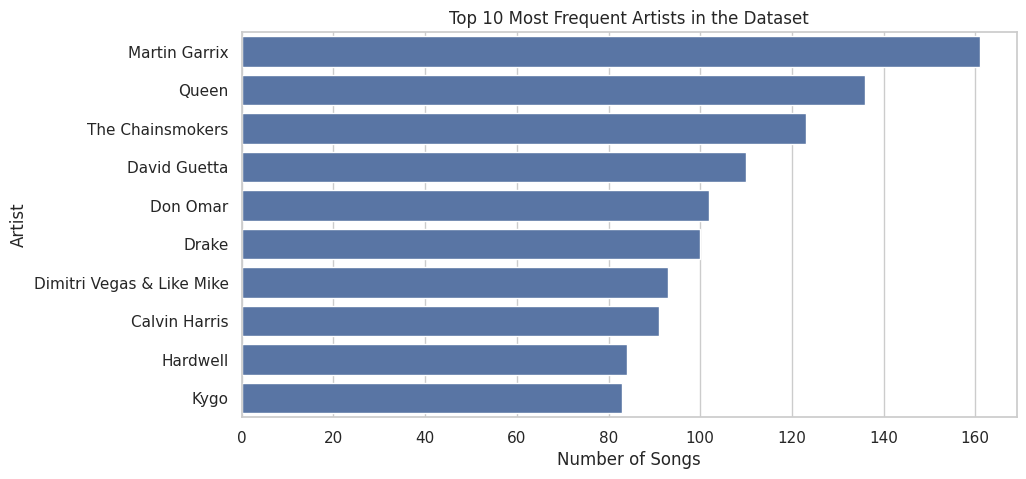


Number of tracks appearing more than once: 3166


,count
track_id,
7BKLCZ1jbUBVqRi2FVlTVw,10
14sOS5L36385FJ3OL8hew4,9
3eekarcy7kvN4yt5ZFzltW,9
2b8fOow8UzyDFAE27YhOZM,8
0sf12qNH5qcw8qpgymFOqD,8
7h0d2h0fUmzbs7zeFigJPn,8
6Gg1gjgKi2AK4e0qzsR7sd,8
6oJ6le65B3SEqPwMRNXWjY,8
0nbXyq5TXYPCO7pr3N8S4I,8


In [13]:
# ARTIST FREQUENCY

if "track_artist" in df.columns:
    top_artists = df["track_artist"].value_counts().head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_artists.values, y=top_artists.index)
    plt.title("Top 10 Most Frequent Artists in the Dataset")
    plt.xlabel("Number of Songs")
    plt.ylabel("Artist")
    plt.show()

# REPEATED TRACKS

if "track_id" in df.columns:
    repeated_track_counts = df["track_id"].value_counts() # If we count by track name instead of ID, we also get different counts because different songs have the same names
    repeated_tracks = repeated_track_counts[repeated_track_counts > 1]
    print(f"\nNumber of tracks appearing more than once: {repeated_tracks.shape[0]}")
    display(repeated_tracks.head(10))

Some artists appear much more frequently than others; there may be potential bias in the dataset. Moreover, repeated tracks confirm that the same song can appear in multiple contexts, as mentioned earlier.

## **3. Data Cleaning**

The dataset is already quite clean, with only a few missing values in some text columns. Since this represents a very small portion of the data, those rows are removed without affecting the overall dataset.

A key characteristic of the dataset is that the same track can appear multiple times across different playlists. Instead of removing these duplicates, we keep them, as they reflect how the same song is used in different contexts. This fits the goal of the project, where we want to compare intrinsic features of the music with contextual information. At the same time, this means that observations are not completely independent, which we take into account when interpreting the results.

Some columns, such as track IDs and playlist IDs, are only identifiers and do not provide useful information for prediction. These are excluded from the modeling process, although they are kept in the dataset for reference.

The release date is converted into a datetime format, and the release year is extracted as a simpler and more useful feature. This allows us to include temporal information without relying on raw date strings

In [14]:
# MAKE A COPY

df_clean = df.copy()
print("Initial shape:", df_clean.shape)

Initial shape: (32833, 23)


We make a copy to work on so that we don't operate directly on the raw data, and we can keep the original dataset for reference in case we need it.

The next step would be to remove full duplicates but since we already found that there are none, and we don't intend to remove the songs that are the same but are in different playlists, we will skip this part.

In [15]:
# CONVERT DATE AND EXTRACT YEAR

df_clean["track_album_release_date"] = pd.to_datetime(
    df_clean["track_album_release_date"],
    errors="coerce")

df_clean["release_year"] = df_clean["track_album_release_date"].dt.year

The release date is converted into a datetime format, and the release year is extracted as a separate feature.

In [17]:
# DROP METADATA COLUMNS

metadata_to_drop = [
    "track_name",
    "track_artist",
    "track_album_name",
    "playlist_name"]

df_model = df_clean.drop(columns=metadata_to_drop)

print("\nDropped metadata columns:")
print(metadata_to_drop)


Dropped metadata columns:
['track_name', 'track_artist', 'track_album_name', 'playlist_name']


Text-based metadata columns are removed from the modeling dataset. These variables are not directly useful for numerical models in their raw form and are excluded to avoid introducing noise. They may, however, be used separately in the NLP part of the project.

In [18]:
# FINAL CHECKS

print("\nFinal cleaned dataset shape:", df_model.shape)
print("Remaining fully duplicated rows:", df_model.duplicated().sum())
print("Unique track_id values:", df_model["track_id"].nunique())
display(df_model.head())


Final cleaned dataset shape: (32833, 20)
Remaining fully duplicated rows: 0
Unique track_id values: 28356


,track_id,track_popularity,track_album_id,track_album_release_date,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year
0,6f807x0ima9a1j3VPbc7VN,66,2oCs0DGTsRO98Gh5ZSl2Cx,2019-06-14,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,2019.0
1,0r7CVbZTWZgbTCYdfa2P31,67,63rPSO264uRjW1X5E6cWv6,2019-12-13,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2019.0
2,1z1Hg7Vb0AhHDiEmnDE79l,70,1HoSmj2eLcsrR0vE9gThr4,2019-07-05,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2019.0
3,75FpbthrwQmzHlBJLuGdC7,60,1nqYsOef1yKKuGOVchbsk6,2019-07-19,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2019.0
4,1e8PAfcKUYoKkxPhrHqw4x,69,7m7vv9wlQ4i0LFuJiE2zsQ,2019-03-05,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,2019.0


## **4. Data Splitting**

Data splitting is used to evaluate models in a fair and realistic way. The dataset is divided into separate subsets so that models are tested on data they have not seen during training.

This step is especially important in our case because the same track can appear multiple times across playlists. If the same song appears in both the training and test sets, the model could perform well simply because it has already seen that track before. This would lead to data leakage and overly optimistic results.

To reduce this risk, we split the data carefully while keeping in mind that observations are not fully independent. The dataset is divided into training, validation and test sets, a structure that allows us to compare models consistently while keeping the test set untouched until the end.

Finally, any preprocessing steps that learn from the data (such as scaling or vectorization) are fitted only on the training set and then applied to the validation and test sets to prevent data leakage.

In [19]:
# SETUP AND COPY

from sklearn.model_selection import train_test_split

df_split = df_model.copy()
print("Dataset shape before splitting:", df_split.shape)

Dataset shape before splitting: (32833, 20)


We create a working copy of the cleaned dataset to perform the splitting step without modifying the original data. This keeps the process safe and reproducible.

In [20]:
# EXTRACT UNIQUE TRACK IDS

unique_tracks = df_split["track_id"].unique()

We extract the unique track IDs to ensure that splitting is done at the track level rather than the row level. This is important because the same track can appear multiple times in different playlists, and we want to avoid leakage.

In [21]:
# SPLIT 1: TRAIN / TEST

train_val_ids, test_ids = train_test_split(
    unique_tracks,
    test_size=0.20,
    random_state=42,
    shuffle=True)

# SPLIT 2: TRAIN / VALIDATION

train_ids, val_ids = train_test_split(
    train_val_ids,
    test_size=0.25,  # 0.25 * 0.8 = 0.2
    random_state=42,
    shuffle=True)

We first split the track IDs into a training/validation set and a test set (80% / 20%). The test set is kept separate and will only be used for final evaluation.

Afterwards, we split the training set between training and validation. Training size = 60%, Validation = 20%, Test = 20%.

In [22]:
# CREATE DATASETS FROM SPLITS

train_df = df_split[df_split["track_id"].isin(train_ids)]
val_df   = df_split[df_split["track_id"].isin(val_ids)]
test_df  = df_split[df_split["track_id"].isin(test_ids)]

We construct the final datasets by selecting all rows corresponding to each group of track IDs. Important note to remember: we do it this way so that each track appears only in one subset, regardless of whether it's present in multiple playlists.

In [23]:
# CHECK SHAPES

print("Training set shape:  ", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:      ", test_df.shape)

Training set shape:   (19713, 20)
Validation set shape: (6559, 20)
Test set shape:       (6561, 20)


We check the sizes to confirm that we performed the split correctly.

In [24]:
# CHECK PROPORTIONS

total_rows = len(df_split)

print("\nProportions:")
print(f"Train:      {len(train_df) / total_rows:.2%}")
print(f"Validation: {len(val_df) / total_rows:.2%}")
print(f"Test:       {len(test_df) / total_rows:.2%}")


Proportions:
Train:      60.04%
Validation: 19.98%
Test:       19.98%


It's approximately 60, 20, 20. Not exact because we performed the split by track ID and not by row.

In [25]:
# OVERLAP CHECK

train_ids_set = set(train_df["track_id"])
val_ids_set   = set(val_df["track_id"])
test_ids_set  = set(test_df["track_id"])

print("\nOverlap checks:")
print("Train ∩ Validation:", len(train_ids_set.intersection(val_ids_set)))
print("Train ∩ Test:      ", len(train_ids_set.intersection(test_ids_set)))
print("Validation ∩ Test: ", len(val_ids_set.intersection(test_ids_set)))


Overlap checks:
Train ∩ Validation: 0
Train ∩ Test:       0
Validation ∩ Test:  0


We explicitly check that there is no overlap between subsets.

In [26]:
# RESET INDEX

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Finally, we reset the indices of each dataset to keep them clean and ready for further processing.

## **5. Missing values**

The dataset initially contains very few missing values, limited to a small number of entries in text-related columns. However, after converting the release date into a datetime format, additional missing values appear due to invalid or incomplete date entries.

These missing values affect only the release date and the derived release year feature, while all core numerical audio features remain complete. Since these features are not central to the main modeling tasks, we handle the missing values by imputing the release year using the median value.

This approach allows us to preserve the full dataset without introducing unnecessary complexity. Overall, the dataset remains reliable for modeling, as the key features used for learning are complete.

In [27]:
# CHECK MISSING VALUES

missing_counts = df_model.isnull().sum()
missing_percent = (df_model.isnull().mean() * 100)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])

,missing_count,missing_percent
track_album_release_date,1886,5.744221
release_year,1886,5.744221


We check for missing values in the cleaned dataset. Almost 1900 missing values appeared after we converted to datetime, likely due to wrong or incomplete date formats.

In [31]:
# HANDLE MISSING VALUES

median_year = df_model["release_year"].median()
df_model["release_year"] = df_model["release_year"].fillna(median_year)

print(f"Filled missing release_year with median: {median_year}")

Filled missing release_year with median: 2017.0


Missing values only affect the release year feature. Instead of removing rows, we fill these values using the median year. This keeps the dataset size unchanged and avoids unnecessary data loss.

In [32]:
# CHECK

print("\nRemaining missing values:")
print(df_model.isnull().sum().sum())


Remaining missing values:
0


We confirm that no missing values remain. The dataset is now complete and ready for the next steps.

## **6. Encoding**

Machine learning models require numerical inputs, so categorical variables need to be handled before modeling. However, not all categorical variables in the dataset are useful as features, and encoding should only be applied where it makes sense.

In this dataset, we distinguish between three types of categorical variables:

- Metadata columns (e.g., track name, artist, playlist name), which are - descriptive and not used as features
- Identifier columns (e.g., track_id, playlist_id), which uniquely identify observations but do not carry predictive information
- Target variables (e.g., playlist_genre or popularity class), which are used as labels in supervised tasks

Since the project focuses on audio features as the main representation of music, most categorical variables are excluded from the input space. Including  variables such as artist or track name would add noise and unnecessary complexity without improving the model.

Encoding is therefore applied only when needed, mainly to transform target variables into a numerical format for classification tasks. This keeps the feature space simple and focused on meaningful information.

In [33]:
# COPY

df_encoded = df_model.copy()

We create a copy of the cleaned dataset to prepare it for encoding. This allows us to modify the feature space without affecting previous steps.

In [34]:
# IDENTIFY CATEGORICAL COLUMNS

categorical_cols = df_encoded.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['track_id', 'track_album_id', 'playlist_id', 'playlist_genre', 'playlist_subgenre']


We identify all categorical variables in the dataset. These include text-based columns, identifiers, and label variables, which need to be handled differently depending on their role.

In [35]:
# REMOVE IDENTIFIER COLUMNS

identifier_cols = ["track_id", "track_album_id", "playlist_id"]

categorical_cols = [col for col in categorical_cols if col not in identifier_cols]

print("\nCategorical columns after removing identifiers:")
print(categorical_cols)


Categorical columns after removing identifiers:
['playlist_genre', 'playlist_subgenre']


Identifier columns are removed from the list of categorical variables, as they do not contain meaningful information for prediction and should not be encoded.

In [36]:
# SEPARATE TARGET VARIABLES

target_cols = ["playlist_genre", "playlist_subgenre"]

print("\nTarget columns (will be encoded later in blocks):")
print(target_cols)


Target columns (will be encoded later in blocks):
['playlist_genre', 'playlist_subgenre']


We define the target variables separately. These will be encoded later depending on the specific task (e.g., classification), rather than applying encoding globally.

In [37]:
# FINAL DATASET STATE

print("\nDataset ready for modeling (no encoding applied globally):")
print(df_encoded.shape)


Dataset ready for modeling (no encoding applied globally):
(30947, 20)


At this stage, no encoding is applied globally. The dataset remains focused on numerical audio features, and categorical variables will be handled separately when required.

## **7. Feature Engineering & Selection**

Feature engineering defines how songs are represented in the models, which directly affects what patterns can be learned. In this project, we focus on building a clear and consistent feature space based on audio characteristics.

### Global Feature Foundation

At the global level, we use Spotify's audio features as the main representation of each song. These include variables such as danceability, energy, loudness, acousticness, valence, tempo, and others.

These features are well suited for modeling because they are numerical, standardized, and directly describe measurable properties of the music. They also have no missing values, which simplifies preprocessing.

We exclude:

- identifier columns (e.g., track_id), since they do not carry predictive information
- text metadata (e.g., track name, artist), which are not part of the audio signal
- high-cardinality categorical variables such as artist, which would add complexity without clear benefit


### Task-Specific Feature Engineering

While the audio features provide a common base, different tasks may require different representations.

For example:

- text-based features (TF-IDF) will be used separately for NLP tasks
- popularity modeling may benefit from combining features or testing different representations
- clustering and dimensionality reduction will use the same features but in a more neutral way


### Feature Selection

At this stage, we keep all core audio features as the baseline and avoid removing variables unless there is a clear reason.

Although some features may be correlated, we do not remove them automatically, since their usefulness depends on the model. The goal is to keep the representation simple while preserving the structure of the data.

In [39]:
# COPY

df_features = df_encoded.copy()

We create a working copy of the dataset to define the feature space used for modeling.

In [40]:
# DEFINE CORE AUDIO FEATURES

core_audio_features = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"]

core_audio_features = [col for col in core_audio_features if col in df_features.columns] # safety check

print("Core audio features:")
print(core_audio_features)

Core audio features:
['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


We define the core set of audio features that will represent each song. These variables capture measurable properties of the music and form the main input for the models.

In [41]:
# FEATURE AND TARGET SELECTION

target_columns = ["playlist_genre", "playlist_subgenre", "track_popularity"]
target_columns = [col for col in target_columns if col in df_features.columns]

df_features = df_features[core_audio_features + target_columns] # keep only relevant columns

print("\nFinal feature set shape:", df_features.shape)


Final feature set shape: (30947, 15)


We keep only the audio features and the target variables to make sure the models focus on meaningful inputs and avoids unnecessary variables.

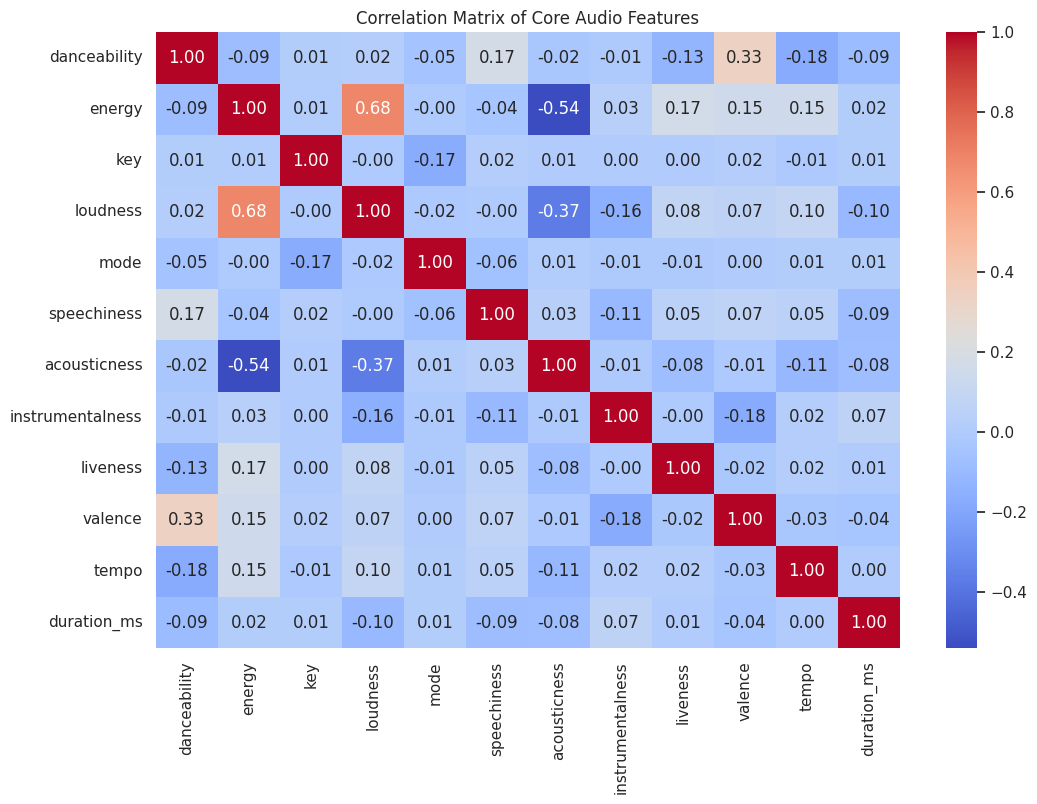

In [42]:
# CORRELATION ANALYSIS

plt.figure(figsize=(12, 8))
corr_matrix = df_features[core_audio_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Core Audio Features")
plt.show()

We analyze correlations between audio features to understand their relationships and to identify redundancies. The heatmap reveals mostly independent features with a few significant relationships that make sense conceptually, such as energy and loudness (+0.68). There are no high correlations.

In [43]:
# IDENTIFY CORRELATIONS

corr_threshold = 0.85

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > corr_threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2))

print("\nHighly correlated feature pairs (> 0.85):")
print(high_corr_pairs if high_corr_pairs else "None")


Highly correlated feature pairs (> 0.85):
None


This confirms that there aren't any highly correlated variables, so we don't need to worry about this in the future. Our feature space seems clean, meaningful and not redundant.

## **8. Feature Scaling**

Feature scaling is used to make sure all numerical features are on a similar scale before training models. In this dataset, audio features have very different ranges. For example, some variables like danceability and valence are between 0 and 1, while others like tempo or loudness have much larger ranges.

If we use the raw values, features with larger scales can dominate the model, even if they are not more important. This mainly affects models that rely on distances or optimization, such as clustering, PCA, or neural networks.

To avoid this, we apply standardization, which rescales each feature to have a mean of 0 and a standard deviation of 1. This makes the features comparable and helps models learn more balanced patterns.

Scaling is fitted only on the training data and then applied to validation and test sets to avoid data leakage.

We define the scaling approach here, but apply it later within model pipelines, since not all models require scaling (for example, tree-based models are less sensitive to it).

In [44]:
# IMPORT AND COPY

from sklearn.preprocessing import StandardScaler
df_scaled = df_features.copy()

We create a copy of the feature dataset to prepare for scaling.

In [45]:
# DEFINE FEATURE MATRIX

target_cols = ["playlist_genre", "playlist_subgenre", "track_popularity"] # exclude target variables

feature_columns = [
    col for col in df_scaled.columns
    if col not in target_cols]

X = df_scaled[feature_columns]

print("Feature columns used for scaling:")
print(feature_columns)

Feature columns used for scaling:
['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


We separate the input features from the target variables. Scaling is applied only to the input features, not to the labels.

In [ ]:
# SCALER

scaler = StandardScaler() # initialize

# SCALING APPROACH TO BE ADDED INSIDE EACH MODEL

# Fit ONLY on training data
# scaler.fit(train_df[feature_columns])

# Then transform all sets
# X_train_scaled = scaler.transform(train_df[feature_columns])
# X_val_scaled   = scaler.transform(val_df[feature_columns])
# X_test_scaled  = scaler.transform(test_df[feature_columns])

print("\nScaler defined. Will be applied inside each modeling block.")

We define a standard scaler, which will be used to normalize the feature values. Scaling is not applied at this stage. Instead, it will be done inside each modeling block. The scaler must be fitted only on the training data and then applied to validation and test sets, to avoid data leakage.


---

# **3. NLP + Neural Networks** (cambiar nombre)

## 3.1 Problem Definition

blafdjsfoas

## 3.2 Text Preprocessing

Interpretation of 3.2

## 3.3 Feature Extraction (TF-IDF)

interpretation of 3.3

## 3.4 Model 1 — Logistic Regression (Baseline)

interpretation of 3.4

## 3.5 Model 2 — Neural Network (MLP)

interpretation of 3.5

## 3.6 Transformer Model

interpretation of 3.6

## 3.7 Feature Importance / Key Terms

interpretation of 3.7

## 3.8 Summary of Textual Representation
interpretation 3.8

# **4. Popularity Predictions** (cambiar nombre)

## 4.1 Problem Definition

fnewjkfnewjk

## 4.2 Target Definition

Interpretation of 4.2

## 4.3 Input Representations

interpretation of 4.3

## 4.4 Baseline Model

In [ ]:
# dummy classifier

interpretation of 4.4

## 4.5 Logistic Regression

In [ ]:
# train

interpretation of 4.5

## 4.6 Random Forest

In [ ]:
# train

interpretation of 4.6

## 4.7 Gradient Boosting

In [ ]:
# train

interpretation of 4.7

## 4.8 Model Comparison

- Which representation works best?
- Does combining inputs help?

## 4.9 Confusion Matrix Analysis

interpretation of 4.9

## 4.10 Summary

conclusions of point 4

# **5. Clustering** (cambiar nombre)

## 5.1 Problem Definition

djekwndjkew

## 5.2 Feature Preparation

interpretation of 5.2

## 5.3 PCA (Dimensionality Reduction)

In [ ]:
# fit pca

interpretation of 5.3

## 5.4 Choosing Number of Clusters

In [ ]:
# elbow method + silhouette score

interpretation of 5.4

## 5.5 K-Means Clustering

interpretation of 5.5

## 5.6 Cluster Profiling

In [ ]:
# compute mean feature values per cluster

interpretatioin of 5.6

## 5.7 Cluster vs Popularity

In [ ]:
# analyze popularity per cluster

## 5.8 Cluster vs NLP Predictions

In [ ]:
# compare clusters with text-based predictions (do text and audio representations agree?)

## 5.9 Summary

conclusions of point 5

# **6. Visualization** (cambiar nombre)

## 6.1 Objective

jewjew

## 6.2 PCA Projection (2D)

interpretation of 6.2

## 6.3 Visualization by Popularity

In [ ]:
# color by popularity

interpretation of 6.3

## 6.4 Visualization by Clusters

In [ ]:
# color by cluster

interpretation of 6.4

## 6.5 Visualization by NLP Predictions

In [ ]:
# color by text prediction

interpretation of 6.5

## 6.6 UMAP

In [ ]:
# umap projection

interpretation of 6.6

## 6.7 conclusions

conclusions of point 6

# **7. Synthesis, Interpretation & Conclusion** (cambiar nombre)

# **8. Conclusion** (cambiar nombre)